# Why `RCALIBFRAC` is not a clean fiber-loss metric -- a side-by-side with `L_field`

`telemetry_mining` provides geometry-based fiber-loss metrics (`L_see`, `L_field`) instead of just
using DESI's standard-star flux ratio `RCALIBFRAC` for one concrete reason: `RCALIBFRAC` carries a
**sky-subtraction artifact** -- a spurious, zenith-tied **dipole** imprinted by an early pipeline
stage, which has nothing to do with the optics or the atmosphere.

This notebook makes that visual. It puts the *per-fiber spatial loss field* of `RCALIBFRAC` next to
that of `L_field` and shows that `RCALIBFRAC`'s dominant coherent feature is the artifact dipole,
while `L_field` shows only the real, symmetric DAR quadrupole.

**The key point for anyone choosing a metric:** an aggregate look at `RCALIBFRAC` -- a histogram, a
scalar correlation -- looks perfectly reasonable, because the artifact is a *directional* effect that
averages away. You only see it when you look at the field **spatially, in a zenith-aligned frame**.
That is exactly why it went unnoticed for so long, and why the geometry-based metrics were built.

## Background

`RCALIBFRAC` $\approx$ measured flux / model flux for a standard star -- the empirical, spectroscopic
estimate of aperture (fiber) loss. A separate investigation (`docs/DAR_FIBER_LOSS_REPORT.md`) found
that its sky-subtraction step imprints a rotating, zenith-tied **dipole** into the per-fiber loss
field.

`L_field` estimates the same physical loss from **guide-camera imaging** (the intra-exposure field
distortion), never touching sky-subtracted flux -- so it structurally cannot carry that artifact -- and
by construction it drops the uniform-offset (dipole) term entirely, keeping only the field-differential
(quadrupole) part (`docs/FIBER_LOSS_METRICS.md`).

DAR physics predicts a **quadrupole** (m=2, a symmetric two-lobed pattern aligned with the zenith).
A **dipole** (m=1, one-sided) in the loss field is *not* something DAR produces -- it's the tell that
a non-physical artifact is present. This notebook needs no database or `desimodel`: it runs purely from
two precomputed per-fiber loss fields, so it works anywhere those files are available.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

TM_ROOT = Path.cwd() if (Path.cwd() / "notebooks").exists() else Path.cwd().parent
print("data root:", TM_ROOT)

data root: /Users/klaus/telemetry_mining-trunk


## Step 1: the two per-fiber loss fields

We compare the two fields on the same high-airmass sample (**airmass > 1.6**, where DAR is largest and
the artifact most prominent):

- **`RCALIBFRAC` loss** (`1 - RCALIBFRAC`) per standard-star fiber, from the assembled calibstars
  dataset -- the flux metric, which carries the artifact.
- **`L_field` loss** per grid point, from the precomputed field
  (`dar_gfa_fiber_loss_metric_v2.parquet`) -- the same map the `L_field` notebook visualizes.

Both are joined to each exposure's parallactic angle (needed to rotate into the zenith frame), and
each field's focal-plane positions are normalized to unit maximum radius so the two are on the same
footing.

In [2]:
pt = pd.read_csv(TM_ROOT / "data" / "dar_exposure_pointing.csv", usecols=["EXPID", "parallactic"])

# RCALIBFRAC per-fiber loss field (flux metric); positions X, Y in focal-plane mm
rc = (pd.read_parquet(TM_ROOT / "notebooks" / "data" / "dar_calibstars_dataset.parquet",
                      columns=["EXPID", "X", "Y", "loss", "airmass"])
        .merge(pt, on="EXPID"))
rc = rc[(rc.airmass > 1.6) & np.isfinite(rc.loss) & rc.loss.between(-0.3, 0.3)
        & np.isfinite(rc.X) & np.isfinite(rc.Y)].copy()

# L_field per-fiber loss field (geometry metric); positions U, V (normalized grid)
lf = pd.read_parquet(TM_ROOT / "data" / "dar_gfa_fiber_loss_metric_v2.parquet")
lf = lf[lf.airmass > 1.6].copy()

# a common unit-max-radius normalization (u, v) so the low-order fits below are on the same footing
rc["u"], rc["v"] = rc.X / np.hypot(rc.X, rc.Y).max(), rc.Y / np.hypot(rc.X, rc.Y).max()
lf["u"], lf["v"] = lf.U / np.hypot(lf.U, lf.V).max(), lf.V / np.hypot(lf.U, lf.V).max()

print(f"RCALIBFRAC: {rc.EXPID.nunique():5d} exposures, {len(rc):6d} fibers")
print(f"L_field   : {lf.EXPID.nunique():5d} exposures, {len(lf):6d} grid points")

RCALIBFRAC:  1035 exposures, 108670 fibers
L_field   :  1026 exposures,  25650 grid points


## Step 2: decompose each field into dipole + quadrupole

Fit each per-fiber loss field to the low-order basis used throughout this investigation -- a radial
term, a **rotating dipole** (`D_rot`, zenith-tied, the artifact) and a **rotating quadrupole**
(`Q_rot`, the real DAR) -- with per-exposure demeaning. The amplitudes tell the story before we plot
anything.

In [3]:
def decompose(d):
    u, v = d.u.values, d.v.values
    q = np.deg2rad(d.parallactic.values); c, s = np.cos(q), np.sin(q)
    up, vp = u * c + v * s, -u * s + v * c          # rotate into the zenith frame
    names = ["rad", "fdx", "fdy", "rdx", "rdy", "fq1", "fq2", "rq1", "rq2"]
    M = np.column_stack([u*u + v*v, u, v, up, vp, u*u - v*v, 2*u*v, up*up - vp*vp, 2*up*vp])
    X = pd.DataFrame(M, columns=names); X["y"] = d.loss.values; X["e"] = d.EXPID.values
    gm = X.groupby("e")[names + ["y"]].transform("mean")     # per-exposure demean
    b = np.linalg.lstsq((X[names] - gm[names]).values, (X["y"] - gm["y"]).values, rcond=None)[0]
    co_ = dict(zip(names, b))
    return np.hypot(co_["rdx"], co_["rdy"]), np.hypot(co_["rq1"], co_["rq2"])   # D_rot, Q_rot

print(f"{'field':22s} {'D_rot (dipole)':>15s} {'Q_rot (quadrupole)':>19s} {'D_rot/Q_rot':>12s}")
for name, d in [("RCALIBFRAC (flux)", rc), ("L_field (geometry)", lf)]:
    Drot, Qrot = decompose(d)
    print(f"{name:22s} {Drot:15.4f} {Qrot:19.4f} {Drot/Qrot:12.2f}")

field                   D_rot (dipole)  Q_rot (quadrupole)  D_rot/Q_rot
RCALIBFRAC (flux)               0.0561              0.0293         1.92
L_field (geometry)              0.0000              0.0160         0.00


**RCALIBFRAC's rotating dipole is about twice its quadrupole** -- the artifact is the *dominant*
coherent structure in the field. **`L_field`'s dipole is ~0** -- it is dropped by construction, leaving
only the real quadrupole. Now the same thing, spatially.

## Step 3: the loss fields, side by side

Bin each per-fiber field in polar coordinates (radius-ring $\times$ angle) in the **zenith-derotated
frame** (each exposure rotated into a common zenith-aligned frame by its parallactic angle), with the
radial (monopole) component subtracted so the angular structure is what you see. A dipole is a
one-sided (red on one side, blue on the opposite) pattern; a quadrupole is a symmetric four-fold one.

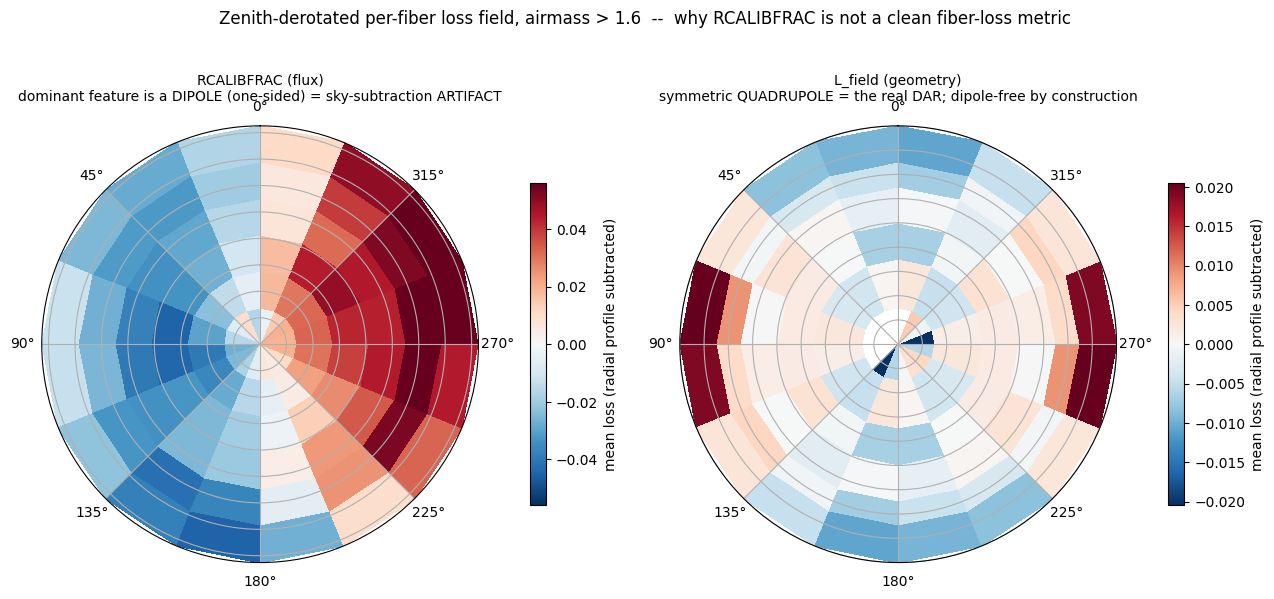

In [4]:
THETA_EDGES = np.linspace(-np.pi, np.pi, 17)   # 16 angular sectors

def derotated_map(d, xcol, ycol, r_edges, min_count):
    q = np.deg2rad(d.parallactic.values); c, s = np.cos(q), np.sin(q)
    x, y = d[xcol].values, d[ycol].values
    up, vp = x * c + y * s, -x * s + y * c          # rotate into the zenith frame
    r, th = np.hypot(up, vp), np.arctan2(vp, up)
    stat, _, _, _ = binned_statistic_2d(r, th, d.loss.values, "mean", bins=[r_edges, THETA_EDGES])
    cnt,  _, _, _ = binned_statistic_2d(r, th, d.loss.values, "count", bins=[r_edges, THETA_EDGES])
    ri = np.clip(np.digitize(r, r_edges) - 1, 0, len(r_edges) - 2)
    mono = np.array([d.loss.values[ri == i].mean() if (ri == i).any() else np.nan
                     for i in range(len(r_edges) - 1)])           # rotation-invariant radial profile
    g = stat - mono[:, None]
    g[cnt < min_count] = np.nan                                    # mask sparse cells
    return g

# bin each field on radial edges matched to its own sampling: RCALIBFRAC is continuous (real fibers),
# the L_field grid has a handful of discrete radii -- shared edges would misfit one or the other.
RC_EDGES = np.linspace(0, np.hypot(rc.X, rc.Y).max(), 7)
LF_EDGES = np.array([0.0, 0.15, 0.35, 0.5, 0.65, 0.75, 0.9])
g_rc = derotated_map(rc, "X", "Y", RC_EDGES, min_count=30)
g_lf = derotated_map(lf, "U", "V", LF_EDGES, min_count=12)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), subplot_kw={"projection": "polar"})
panels = [(axes[0], g_rc, RC_EDGES, "RCALIBFRAC (flux)",
           "dominant feature is a DIPOLE (one-sided) = sky-subtraction ARTIFACT"),
          (axes[1], g_lf, LF_EDGES, "L_field (geometry)",
           "symmetric QUADRUPOLE = the real DAR; dipole-free by construction")]
for ax, g, r_edges, title, sub in panels:
    vmax = np.nanpercentile(np.abs(g[np.isfinite(g)]), 97)
    Theta, Rgrid = np.meshgrid(THETA_EDGES, r_edges)
    im = ax.pcolormesh(Theta, Rgrid, g, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="flat")
    ax.set_title(f"{title}\n{sub}", fontsize=10, pad=18)
    ax.set_theta_zero_location("N"); ax.set_yticklabels([])
    fig.colorbar(im, ax=ax, shrink=0.6, pad=0.09, label="mean loss (radial profile subtracted)")
fig.suptitle("Zenith-derotated per-fiber loss field, airmass > 1.6  --  "
             "why RCALIBFRAC is not a clean fiber-loss metric", fontsize=12, y=1.03)
fig.tight_layout()
plt.show()

**The contrast is the whole point.** `RCALIBFRAC` (left) is a **dipole** -- red on one side, blue
on the opposite -- a one-sided pattern DAR cannot produce; it is the sky-subtraction artifact.
`L_field` (right) is a **quadrupole** -- the symmetric four-fold pattern DAR actually makes, with no
dipole.

And none of this is visible in aggregate: a histogram of `RCALIBFRAC` loss, or its correlation with
airmass, averages over direction and looks fine. The artifact only appears when the field is viewed
**spatially, in a zenith-aligned frame** -- the reason the geometry-based metrics exist.

## Summary

- `RCALIBFRAC`'s per-fiber loss field is dominated by a **rotating dipole** (~2$\times$ the real DAR
  quadrupole) -- a sky-subtraction artifact, not optics or atmosphere.
- `L_field` (and `L_see`), built from guide-camera geometry and dropping the dipole term by
  construction, carry **no such artifact** -- `L_field`'s field is the clean DAR quadrupole.
- The artifact is **invisible in aggregate/scalar views** and only appears in the spatial,
  zenith-derotated map. That is why these artifact-free metrics were built.

**For more:** `docs/FIBER_LOSS_METRICS.md` (metric definitions), `docs/DAR_FIBER_LOSS_REPORT.md` (the
investigation this came out of), and the companion notebooks `lfield_dam_example.ipynb` /
`mirror_seeing_lsee_example.ipynb`.